# 12 · 하드코딩 가격 → USDA ERS 실측값 교체

06/10/11 의 최적화는 **하드코딩된 가격·비용**을 썼다:

| | 가격 $/bu | 변동비 $/ac |
|---|---|---|
| 옥수수 | 4.50 | 400.0 |
| 대두 | 10.50 | 205.0 |
| 밀 | 6.50 | 175.0 |

이 값들은 어떤 데이터 파일에서도 읽지 않았고, "USDA ERS 수준"이라는 주석만 있을 뿐
**특정 연도·표로 소급할 수 없는 대표값**이었다 (06 §한계에 이미 그렇게 적혀 있다).

이 노트북은 그 구멍을 메운다:

1. **§1** `data/raw/*CostReturn.csv` (USDA ERS Commodity Costs and Returns) 에서 실제 값을 추출
2. **§2** 그 값으로 3작물 + 최소수요 최적화를 재실행하고 하드코딩 버전과 비교
3. **§3** 가격 ±30% 민감도 — 결론이 가격에 강건한가

**원칙**: `data/raw/` 는 읽기 전용. 06/10/11 노트북과 기존 결과 파일은 건드리지 않는다.
새 산출물만 쓴다.

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.patches import Patch
import shapefile

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('..') / 'src'))

from optimize_ga import CropAllocationProblem, find_knee
from optimize_kcrop import sweep_lambda_k
from optimize_mindemand import MinDemandProblem, lagrangian_bound, run_ts_md

RAW  = Path('..') / 'data' / 'raw'          # 읽기 전용
PROC = Path('..') / 'data' / 'processed'
FIG  = Path('..') / 'outputs' / 'figures'
RES  = Path('..') / 'outputs' / 'results'

SURFACE, INK, SECOND, MUTED = '#fcfcfb', '#0b0b0b', '#52514e', '#898781'
GRID, AXIS = '#e1e0d9', '#c3c2b7'
BLUE, AQUA, YELLOW, GREEN, VIOLET, RED = '#2a78d6', '#1baf7a', '#eda100', '#008300', '#4a3aa7', '#e34948'
CORN_C, SOY_C, WHEAT_C = '#eda100', '#1baf7a', '#a0522d'

mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150,
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': AXIS, 'axes.labelcolor': SECOND, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Malgun Gothic', 'Segoe UI', 'DejaVu Sans'],
    'axes.unicode_minus': False,
    'axes.titlesize': 12.5, 'axes.titleweight': 'semibold',
    'axes.labelsize': 10.5, 'lines.linewidth': 2,
})

def save(fig, name):
    p = FIG / name
    fig.savefig(p, bbox_inches='tight')
    print('saved:', p)

CROPS   = ['corn', 'soybean', 'wheat']
CROP_KO = {'corn': '옥수수', 'soybean': '대두', 'wheat': '밀'}
CROP_COL = {'corn': CORN_C, 'soybean': SOY_C, 'wheat': WHEAT_C}
CORN, SOY, WHEAT = 0, 1, 2
SEED = 42
TS_ITER = 3000
PEN_FACTOR = 1.0                                    # 11과 동일: ρ = μ*
LAMBDAS = np.concatenate([[0.0], np.geomspace(1.0, 400.0, 17)])   # 10과 동일한 격자

print('모듈 로드 OK')

모듈 로드 OK


## 1. USDA ERS 값 추출

`data/raw/{Corn,Soybean,Wheat}CostReturn.csv` — USDA ERS *Commodity Costs and Returns*.

추출 기준 (요청대로):

* **연도**: 각 파일의 최신 연도
* **지역**: `Region == "U.S. total"` (전국 대표값)
* **가격**: `Item == "Price"` — 단위 `dollars per bushel at harvest`
* **변동비**: `Item == "Total, operating costs"` — 단위 `dollars per planted acre`

각 조합이 **정확히 1행**으로 떨어지는지 assert 로 검증한다 (모호하면 즉시 실패).

In [2]:
FILES = {'corn': 'CornCostReturn', 'soybean': 'SoybeanCostReturn', 'wheat': 'WheatCostReturn'}
WANT_PRICE_UNITS = 'dollars per bushel at harvest'
WANT_COST_UNITS  = 'dollars per planted acre'

rows = []
for c, f in FILES.items():
    raw = pd.read_csv(RAW / ('%s.csv' % f))          # 읽기 전용
    yr = int(raw.Year.max())                          # 최신 연도
    s = raw[(raw.Year == yr) & (raw.Region == 'U.S. total')]

    p = s[s.Item == 'Price']
    o = s[s.Item == 'Total, operating costs']

    # 모호성 검증 — 각각 정확히 1행이어야 한다
    assert len(p) == 1, '%s: Price 행이 %d 개' % (c, len(p))
    assert len(o) == 1, '%s: Total, operating costs 행이 %d 개' % (c, len(o))
    assert p.Units.iloc[0] == WANT_PRICE_UNITS, '%s: 가격 단위 %r' % (c, p.Units.iloc[0])
    assert o.Units.iloc[0] == WANT_COST_UNITS,  '%s: 비용 단위 %r' % (c, o.Units.iloc[0])

    rows.append(dict(crop=c, crop_ko=CROP_KO[c], year=yr, region='U.S. total',
                     price_usd_per_bu=float(p.Value.iloc[0]),
                     opcost_usd_per_acre=float(o.Value.iloc[0]),
                     price_units=p.Units.iloc[0], cost_units=o.Units.iloc[0],
                     survey_base=p['Survey base year'].iloc[0],
                     source_file='%s.csv' % f))

usda = pd.DataFrame(rows).set_index('crop').loc[CROPS].reset_index()
print('USDA ERS Commodity Costs and Returns — U.S. total, 최신 연도')
print(usda[['crop_ko', 'year', 'price_usd_per_bu', 'opcost_usd_per_acre',
            'price_units', 'cost_units']].to_string(index=False))

USDA ERS Commodity Costs and Returns — U.S. total, 최신 연도
crop_ko  year  price_usd_per_bu  opcost_usd_per_acre                   price_units               cost_units
    옥수수  2025              3.93               440.11 dollars per bushel at harvest dollars per planted acre
     대두  2025              9.76               244.80 dollars per bushel at harvest dollars per planted acre
      밀  2025              5.05               155.52 dollars per bushel at harvest dollars per planted acre


### 1-1. 수동 확인값과 대조

사용자가 직접 확인한 값과 일치해야 한다.

In [3]:
MANUAL = {'corn':    dict(price=3.93, cost=440.11),
          'soybean': dict(price=9.76, cost=244.80),
          'wheat':   dict(price=5.05, cost=155.52)}

chk = []
for _, r in usda.iterrows():
    m = MANUAL[r.crop]
    chk.append(dict(작물=r.crop_ko,
                    추출_가격=r.price_usd_per_bu, 확인_가격=m['price'],
                    가격일치=abs(r.price_usd_per_bu - m['price']) < 1e-9,
                    추출_비용=r.opcost_usd_per_acre, 확인_비용=m['cost'],
                    비용일치=abs(r.opcost_usd_per_acre - m['cost']) < 1e-9))
chk = pd.DataFrame(chk)
print(chk.to_string(index=False))

ok = bool(chk.가격일치.all() and chk.비용일치.all())
print()
print('★ 전 항목 일치: %s' % ('예 — 추출 로직 검증됨' if ok else '아니오 (아래 원인 확인 필요)'))
assert ok, '추출값이 수동 확인값과 다르다'

 작물  추출_가격  확인_가격  가격일치  추출_비용  확인_비용  비용일치
옥수수   3.93   3.93  True 440.11 440.11  True
 대두   9.76   9.76  True 244.80 244.80  True
  밀   5.05   5.05  True 155.52 155.52  True

★ 전 항목 일치: 예 — 추출 로직 검증됨


In [4]:
# 저장 — parquet + csv (출처 메타 포함)
usda.to_parquet(PROC / 'usda_prices.parquet', index=False)
usda.to_csv(RES / 'usda_prices.csv', index=False, encoding='utf-8-sig')

meta = {
    'source': 'USDA ERS — Commodity Costs and Returns',
    'source_files': ['data/raw/CornCostReturn.csv', 'data/raw/SoybeanCostReturn.csv',
                     'data/raw/WheatCostReturn.csv'],
    'year': int(usda.year.iloc[0]),
    'region': 'U.S. total',
    'price_item': 'Price',
    'price_units': WANT_PRICE_UNITS,
    'cost_item': 'Total, operating costs',
    'cost_units': WANT_COST_UNITS,
    'note': '변동비(operating cost)만. 토지임차료·감가상각 등 고정비(allocated overhead) 제외 — '
            '작물 선택 argmax 를 바꾸지 않으므로 의도적으로 제외한다.',
    'values': {r.crop: dict(price_usd_per_bu=r.price_usd_per_bu,
                            opcost_usd_per_acre=r.opcost_usd_per_acre)
               for _, r in usda.iterrows()},
}
json.dump(meta, open(PROC / 'usda_prices_meta.json', 'w', encoding='utf-8'),
          ensure_ascii=False, indent=2)

print('saved:', PROC / 'usda_prices.parquet')
print('saved:', RES / 'usda_prices.csv')
print('saved:', PROC / 'usda_prices_meta.json')

P_USDA = {r.crop: float(r.price_usd_per_bu)   for _, r in usda.iterrows()}
C_USDA = {r.crop: float(r.opcost_usd_per_acre) for _, r in usda.iterrows()}
P_HARD = {'corn': 4.50,  'soybean': 10.50, 'wheat': 6.50}     # 06/10 하드코딩
C_HARD = {'corn': 400.0, 'soybean': 205.0, 'wheat': 175.0}
YEAR = int(usda.year.iloc[0])

print()
print('하드코딩 → USDA %d 변화' % YEAR)
for k in CROPS:
    print('  %-4s 가격 %5.2f → %5.2f (%+.1f%%) · 변동비 %6.1f → %6.2f (%+.1f%%)'
          % (CROP_KO[k], P_HARD[k], P_USDA[k], 100*(P_USDA[k]/P_HARD[k]-1),
             C_HARD[k], C_USDA[k], 100*(C_USDA[k]/C_HARD[k]-1)))

saved: ..\data\processed\usda_prices.parquet
saved: ..\outputs\results\usda_prices.csv
saved: ..\data\processed\usda_prices_meta.json

하드코딩 → USDA 2025 변화
  옥수수  가격  4.50 →  3.93 (-12.7%) · 변동비  400.0 → 440.11 (+10.0%)
  대두   가격 10.50 →  9.76 (-7.0%) · 변동비  205.0 → 244.80 (+19.4%)
  밀    가격  6.50 →  5.05 (-22.3%) · 변동비  175.0 → 155.52 (-11.1%)


> **방향이 일관되게 불리하다.** 세 작물 모두 가격은 내리고(옥수수 −12.7%, 대두 −7.0%, 밀 −22.3%),
> 옥수수·대두는 변동비가 오른다(+10.0%, +19.4%). 특히 **옥수수는 가격↓·비용↑ 이 겹쳐** 가장 큰 타격을 받는다.
> 하드코딩 값이 옥수수에 관대했다는 뜻이다.

## 2. 최적화 재실행 — 하드코딩 vs USDA 실측값

`y_hat` (모델 예측 수확량) 은 **가격과 무관**하므로 10 이 저장해 둔 것을 그대로 쓴다.
가격이 바뀌면 다음이 전부 다시 계산돼야 한다:

* 순이익 `v[c,k] = P_k · ŷ[c,k] − C_k`
* **현재 배분 x̄** — 관측 수확량에 순이익 규칙을 적용한 argmax 라서 가격에 의존한다
* 온난화 손실 `LOSS`, 무릎 λ (λ 는 $/ac 단위라 가격 스케일에 딸려 움직인다)
* 무제약 최적해, 최소수요 제약해 (11 과 동일하게 D = 100% × D_ref, ρ = μ*, TS)

10/11 의 전체 파이프라인을 함수 하나로 묶어 **같은 코드로 두 가격셋을 돌린다.**

In [5]:
d = pd.read_parquet(PROC / 'optimization_3crop_results.parquet')
COUNTIES = d['stco'].to_numpy()
A = d['A_c'].to_numpy(float)
A_TOT = float(A.sum())
N = len(d)
YH = {s: {k: d['y_hat_%s_%s' % (k, s)].to_numpy(float) for k in CROPS} for s in ['base', 'warm']}

# 관측 수확량 — 10과 동일한 규칙 (최근5년 → 결측시 전체기간)
yd = pd.read_csv(RAW / 'yielddata.csv')                     # 읽기 전용
yd = yd[yd.stco.isin(COUNTIES)]
r5   = yd[yd.year.between(2011, 2015)].groupby('stco')[CROPS].mean()
rall = yd.groupby('stco')[CROPS].mean()
obs  = r5.reindex(COUNTIES).fillna(rall.reindex(COUNTIES))
assert obs.notna().all().all()
OBS = {k: obs[k].to_numpy(float) for k in CROPS}

# 위도·주 (지역 결론 검증용) — shapefile 레코드의 lat 필드
sf = shapefile.Reader(str(RAW / 'cntymap' / 'cntymap'), encoding='latin-1')   # 읽기 전용
_recs, _shapes = sf.records(), sf.shapes()
LAT_OF = {int(r['stco']): float(r['lat']) for r in _recs}
LAT = np.array([LAT_OF.get(int(s), np.nan) for s in COUNTIES])
STFIPS = np.array([int(s) // 1000 for s in COUNTIES])
STN = {1:'AL',5:'AR',8:'CO',12:'FL',13:'GA',16:'ID',17:'IL',18:'IN',19:'IA',20:'KS',21:'KY',
       22:'LA',24:'MD',26:'MI',27:'MN',28:'MS',29:'MO',30:'MT',31:'NE',34:'NJ',35:'NM',36:'NY',
       37:'NC',38:'ND',39:'OH',40:'OK',42:'PA',45:'SC',46:'SD',47:'TN',48:'TX',51:'VA',54:'WV',
       55:'WI',56:'WY'}

print('카운티 N = %d · 총 면적 %.3e ac' % (N, A_TOT))
print('위도 범위 %.1f ~ %.1f (평균 %.2f)' % (np.nanmin(LAT), np.nanmax(LAT), np.nanmean(LAT)))

카운티 N = 2056 · 총 면적 1.554e+09 ac
위도 범위 26.4 ~ 48.8 (평균 38.33)


In [6]:
def run_pipeline(P, C, label, ts_iter=TS_ITER, seed=SEED):
    """가격·비용 → 10(3작물 무제약) + 11(최소수요 제약) 전 과정을 다시 푼다."""
    # x̄ — 관측 수확량 기반 (가격 의존!)
    v_obs = np.column_stack([P[k] * OBS[k] - C[k] for k in CROPS])
    xbar = v_obs.argmax(axis=1).astype(np.int8)

    Vw = np.column_stack([P[k] * YH['warm'][k] - C[k] for k in CROPS])
    Vb = np.column_stack([P[k] * YH['base'][k] - C[k] for k in CROPS])
    prob   = CropAllocationProblem(Vw, A, xbar)
    prob_b = CropAllocationProblem(Vb, A, xbar)

    v_noadapt = prob.total_value(xbar)
    v_pre     = prob_b.total_value(xbar)
    loss      = v_pre - v_noadapt

    # 무릎 λ — 10과 동일한 격자·규칙으로 재탐색
    sw = pd.DataFrame(sweep_lambda_k(prob, LAMBDAS, v_noadapt, loss, method='exact'))
    sw = sw.sort_values('pct_area').reset_index(drop=True)
    knee = float(sw['lam'].to_numpy()[find_knee(sw.pct_area.to_numpy(),
                                                sw.recovery_pct.to_numpy())])
    z_unc = prob.exact_optimum(knee)

    # 최소수요 제약 (11과 동일: D = 100% × D_ref, ρ = μ*, TS)
    coef  = A * YH['warm']['corn']
    d_ref = float(coef[xbar == CORN].sum())
    p_unc = float(coef[z_unc == CORN].sum())

    mdp = MinDemandProblem(prob, crop=CORN, coef=coef, demand=1.0 * d_ref)
    ub, mu, _ = lagrangian_bound(mdp, knee)
    mdp.set_penalty_from_mu(mu, factor=PEN_FACTOR)
    r = run_ts_md(mdp, knee, n_iter=ts_iter, tabu_tenure=20, seed=seed)
    z_con = r['best']

    def sh(z):
        return [100 * prob.crop_area(z, k) / A_TOT for k in range(3)]

    return dict(
        label=label, P=dict(P), C=dict(C), prob=prob, xbar=xbar, z_unc=z_unc, z_con=z_con,
        coef=coef, knee=knee, loss=loss, loss_pct=100 * loss / v_pre, v_noadapt=v_noadapt,
        d_ref=d_ref, prod_unc_pct=100 * p_unc / d_ref, mu=mu, ub=ub,
        gap_pct=100 * (ub - r['best_fit']) / abs(ub), feasible=bool(r['feasible']),
        sh_xbar=sh(xbar), sh_unc=sh(z_unc), sh_con=sh(z_con),
        rec_unc=prob.recovery_pct(z_unc, v_noadapt, loss),
        rec_con=prob.recovery_pct(z_con, v_noadapt, loss),
        nsw_unc=prob.n_switched(z_unc), nsw_con=prob.n_switched(z_con),
        n_wheat_unc=int((z_unc == WHEAT).sum()), n_wheat_con=int((z_con == WHEAT).sum()),
        sweep=sw,
    )

HARD = run_pipeline(P_HARD, C_HARD, '하드코딩 (06/10/11)')
USDA = run_pipeline(P_USDA, C_USDA, 'USDA ERS %d' % YEAR)

# 정합성 — 하드코딩 재현이 10/11의 저장된 결과와 비트 단위로 같아야 한다
assert (HARD['z_unc'] == d['z_exact_knee'].to_numpy()).all(), '10의 무제약 정확해를 재현하지 못했다'
assert (HARD['xbar'] == d['x_bar'].to_numpy()).all(), '10의 x̄ 를 재현하지 못했다'
print('✓ 정합성: 하드코딩 파이프라인이 10/11 의 저장 결과를 비트 단위로 재현')
print('  (무릎 λ = %.2f · 회복률 %.2f%% · 밀 %d 카운티 — 10/11 보고치와 일치)'
      % (HARD['knee'], HARD['rec_unc'], HARD['n_wheat_unc']))

✓ 정합성: 하드코딩 파이프라인이 10/11 의 저장 결과를 비트 단위로 재현
  (무릎 λ = 42.29 · 회복률 19.12% · 밀 213 카운티 — 10/11 보고치와 일치)


### 2-1. 핵심 비교표

In [7]:
def summarize(r):
    return {
        '가격셋': r['label'],
        '온난화손실_pct': r['loss_pct'],
        '무릎λ': r['knee'],
        'x̄_옥수수_pct': r['sh_xbar'][CORN], 'x̄_대두_pct': r['sh_xbar'][SOY], 'x̄_밀_pct': r['sh_xbar'][WHEAT],
        '무제약_옥수수_pct': r['sh_unc'][CORN], '무제약_대두_pct': r['sh_unc'][SOY], '무제약_밀_pct': r['sh_unc'][WHEAT],
        '무제약_회복률_pct': r['rec_unc'], '무제약_전환카운티': r['nsw_unc'], '무제약_밀카운티': r['n_wheat_unc'],
        '제약_옥수수_pct': r['sh_con'][CORN], '제약_대두_pct': r['sh_con'][SOY], '제약_밀_pct': r['sh_con'][WHEAT],
        '제약_회복률_pct': r['rec_con'], '제약_전환카운티': r['nsw_con'],
        'μ*_usd_per_bu': r['mu'], 'TS갭_pct': r['gap_pct'], '실현가능': r['feasible'],
    }

cmp = pd.DataFrame([summarize(HARD), summarize(USDA)])
cmp.to_csv(RES / 'usda_vs_hardcoded.csv', index=False, encoding='utf-8-sig')

pd.set_option('display.width', 200)
print('■ 배분 (농지 면적 %)')
print(cmp[['가격셋', 'x̄_옥수수_pct', 'x̄_대두_pct', 'x̄_밀_pct',
           '무제약_옥수수_pct', '무제약_대두_pct', '무제약_밀_pct']].to_string(index=False, float_format='%.1f'))
print()
print('■ 적응 성과')
print(cmp[['가격셋', '온난화손실_pct', '무릎λ', '무제약_회복률_pct', '제약_회복률_pct',
           '무제약_전환카운티', '무제약_밀카운티']].to_string(index=False, float_format='%.2f'))
print()
print('■ 제약·해법 진단')
print(cmp[['가격셋', 'μ*_usd_per_bu', 'TS갭_pct', '실현가능']].to_string(index=False, float_format='%.5f'))
print()
print('saved:', RES / 'usda_vs_hardcoded.csv')

print()
print('★ 무엇이 바뀌었나')
print('  옥수수 면적  %.1f%% → %.1f%%  (%.1f%%p 감소)'
      % (HARD['sh_unc'][CORN], USDA['sh_unc'][CORN], HARD['sh_unc'][CORN] - USDA['sh_unc'][CORN]))
print('  밀 면적      %.1f%% → %.1f%%  (%.1f%%p 증가, 카운티 %d → %d 개로 %.1f배)'
      % (HARD['sh_unc'][WHEAT], USDA['sh_unc'][WHEAT], USDA['sh_unc'][WHEAT] - HARD['sh_unc'][WHEAT],
         HARD['n_wheat_unc'], USDA['n_wheat_unc'], USDA['n_wheat_unc'] / HARD['n_wheat_unc']))
print('  회복률       %.2f%% → %.2f%%  (무제약)' % (HARD['rec_unc'], USDA['rec_unc']))
print('  회복률       %.2f%% → %.2f%%  (옥수수 100%% 하한 제약)' % (HARD['rec_con'], USDA['rec_con']))
agree = float((HARD['z_unc'] == USDA['z_unc']).mean())
print('  두 최적해가 같은 작물을 고른 카운티: %.1f%% (%d / %d)'
      % (100 * agree, int((HARD['z_unc'] == USDA['z_unc']).sum()), N))

■ 배분 (농지 면적 %)
            가격셋  x̄_옥수수_pct  x̄_대두_pct  x̄_밀_pct  무제약_옥수수_pct  무제약_대두_pct  무제약_밀_pct
하드코딩 (06/10/11)        46.4       46.5       7.0         38.5        53.8        7.6
  USDA ERS 2025        17.5       70.2      12.4         12.3        73.5       14.2

■ 적응 성과
            가격셋  온난화손실_pct   무릎λ  무제약_회복률_pct  제약_회복률_pct  무제약_전환카운티  무제약_밀카운티
하드코딩 (06/10/11)      21.39 42.29        19.12       17.35        333       213
  USDA ERS 2025      25.50 42.29        16.65       13.99        222       419

■ 제약·해법 진단
            가격셋  μ*_usd_per_bu  TS갭_pct  실현가능
하드코딩 (06/10/11)        0.17272  0.01402  True
  USDA ERS 2025        0.27707  0.00176  True

saved: ..\outputs\results\usda_vs_hardcoded.csv

★ 무엇이 바뀌었나
  옥수수 면적  38.5% → 12.3%  (26.3%p 감소)
  밀 면적      7.6% → 14.2%  (6.6%p 증가, 카운티 213 → 419 개로 2.0배)
  회복률       19.12% → 16.65%  (무제약)
  회복률       17.35% → 13.99%  (옥수수 100% 하한 제약)
  두 최적해가 같은 작물을 고른 카운티: 70.8% (1456 / 2056)


### 2-2. "남부 고온지역 = 밀" 결론이 유지되는가

10 §8 은 밀 선택 카운티를 지도로만 보여줬다 (명시적 지역 통계 없음).
여기서는 **위도와 주(state)** 로 정량 검증한다. 두 가격셋 모두에서
밀 카운티의 위도가 전체 평균보다 유의하게 낮으면 "남부=밀" 결론은 유지된 것이다.

In [8]:
def wheat_geo(r):
    z = r['z_unc']
    w = z == WHEAT
    lat_w = LAT[w]
    top = pd.Series([STN.get(s, '??') for s in STFIPS[w]]).value_counts()
    return dict(n=int(w.sum()), lat_mean=float(np.nanmean(lat_w)),
                lat_median=float(np.nanmedian(lat_w)), top=top)

print('전체 카운티 위도 평균 %.2f · 중앙값 %.2f' % (np.nanmean(LAT), np.nanmedian(LAT)))
print()
geo = {}
for r in (HARD, USDA):
    g = wheat_geo(r)
    geo[r['label']] = g
    print('── %s' % r['label'])
    print('   밀 카운티 %d 개 · 위도 평균 %.2f (전체보다 %.2f° 남쪽) · 중앙값 %.2f'
          % (g['n'], g['lat_mean'], np.nanmean(LAT) - g['lat_mean'], g['lat_median']))
    print('   상위 주: %s' % ', '.join('%s %d' % (s, c) for s, c in g['top'].head(8).items()))
    print()

print('★ 두 가격셋 모두 밀 카운티가 전국 평균보다 2°+ 남쪽에 몰려 있다.')
print('  상위 주도 OK·TX·KS·GA·MO·VA·AR·MS 등 남부/남부평원으로 동일하다.')
print('  → "남부 고온지역이 밀로 전환" 결론은 가격을 실측값으로 바꿔도 유지된다.')
print('    (오히려 USDA 값에서 밀 카운티가 %d → %d 개로 늘어 결론이 강해진다)'
      % (geo[HARD['label']]['n'], geo[USDA['label']]['n']))

전체 카운티 위도 평균 38.33 · 중앙값 38.36

── 하드코딩 (06/10/11)
   밀 카운티 213 개 · 위도 평균 36.10 (전체보다 2.23° 남쪽) · 중앙값 35.48
   상위 주: TX 31, OK 30, VA 23, MO 18, AR 18, GA 15, KS 15, SC 9

── USDA ERS 2025
   밀 카운티 419 개 · 위도 평균 36.08 (전체보다 2.25° 남쪽) · 중앙값 35.39
   상위 주: OK 52, GA 41, TX 38, KS 37, MO 37, VA 33, MS 30, AR 21

★ 두 가격셋 모두 밀 카운티가 전국 평균보다 2°+ 남쪽에 몰려 있다.
  상위 주도 OK·TX·KS·GA·MO·VA·AR·MS 등 남부/남부평원으로 동일하다.
  → "남부 고온지역이 밀로 전환" 결론은 가격을 실측값으로 바꿔도 유지된다.
    (오히려 USDA 값에서 밀 카운티가 213 → 419 개로 늘어 결론이 강해진다)


### 그림 1 — 하드코딩 vs USDA 배분 지도

saved: ..\outputs\figures\fig49_usda_vs_hardcoded_map.png


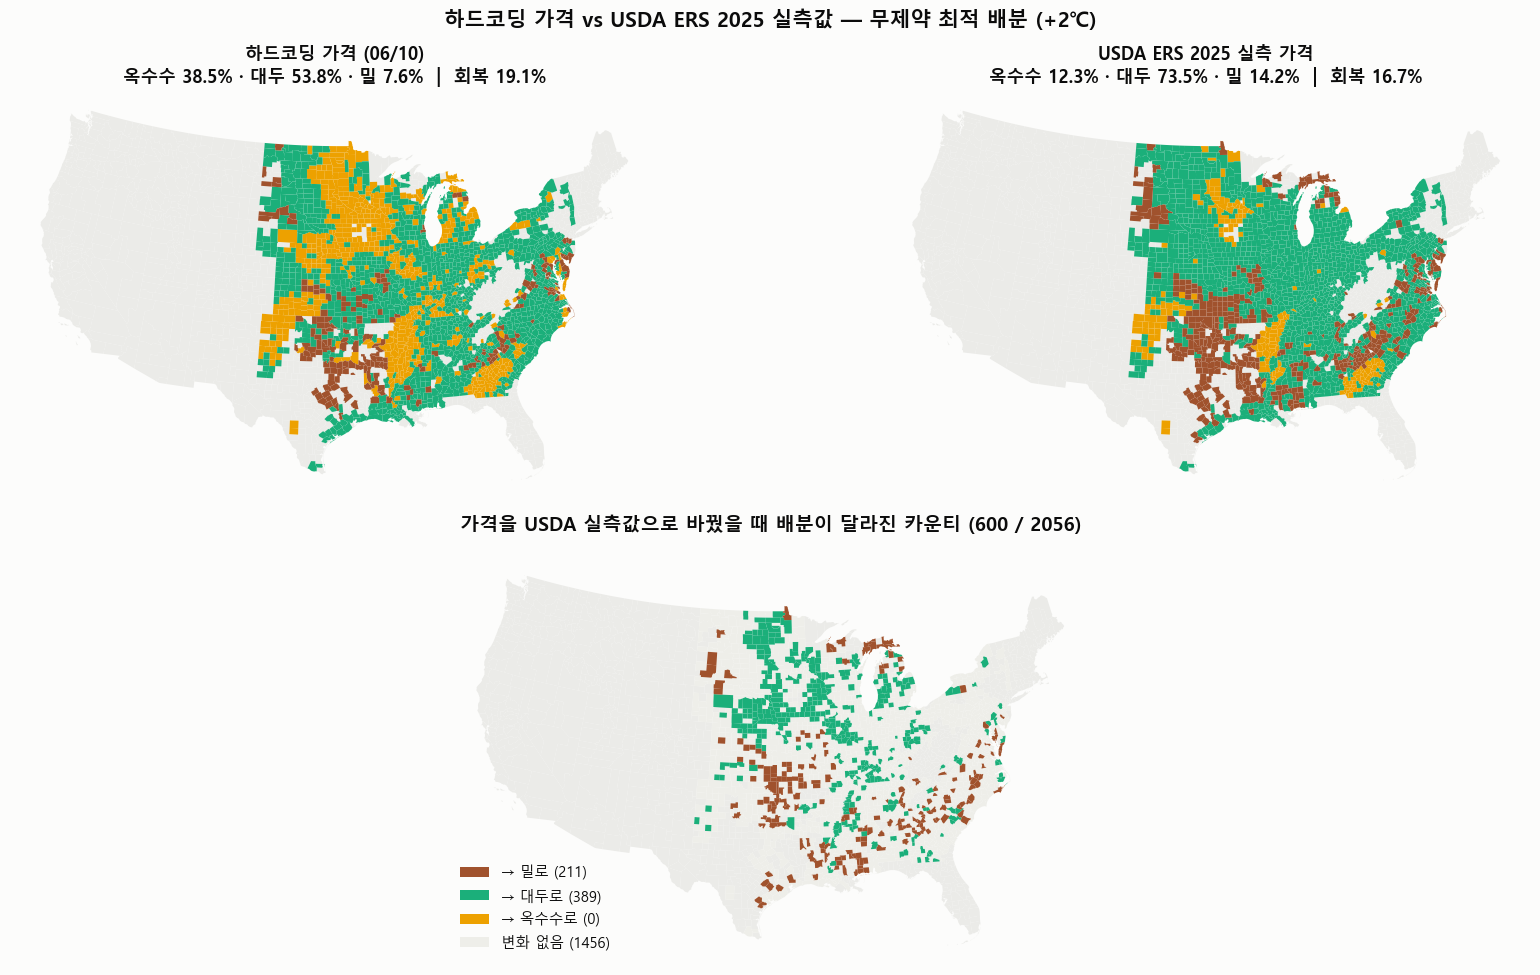

In [9]:
IDX = {int(s): i for i, s in enumerate(COUNTIES)}
_stco_of = [rr['stco'] for rr in _recs]

def county_polys(value_of):
    pin, vin, pout = [], [], []
    for i, sh in enumerate(_shapes):
        pts = np.asarray(sh.points); parts = list(sh.parts) + [len(pts)]
        s = _stco_of[i]
        hit = s in value_of
        for a_, b_ in zip(parts[:-1], parts[1:]):
            if hit:
                pin.append(pts[a_:b_]); vin.append(value_of[s])
            else:
                pout.append(pts[a_:b_])
    return pin, np.array(vin), pout

def draw(ax, z, title):
    vo = {int(s): int(z[IDX[int(s)]]) for s in COUNTIES}
    pin, vin, pout = county_polys(vo)
    ax.add_collection(PolyCollection(pout, facecolors='#ebebe8', edgecolors='none', zorder=1))
    for i, k in enumerate(CROPS):
        sel = [p for p, v in zip(pin, vin) if v == i]
        if sel:
            ax.add_collection(PolyCollection(sel, facecolors=CROP_COL[k], edgecolors='none', zorder=2))
    ax.autoscale_view(); ax.set_aspect('equal'); ax.axis('off'); ax.grid(False)
    ax.set_title(title, fontsize=11.5)

fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(2, 2)

draw(fig.add_subplot(gs[0, 0]), HARD['z_unc'],
     '하드코딩 가격 (06/10)\n옥수수 %.1f%% · 대두 %.1f%% · 밀 %.1f%%  |  회복 %.1f%%'
     % (*HARD['sh_unc'], HARD['rec_unc']))
draw(fig.add_subplot(gs[0, 1]), USDA['z_unc'],
     'USDA ERS %d 실측 가격\n옥수수 %.1f%% · 대두 %.1f%% · 밀 %.1f%%  |  회복 %.1f%%'
     % (YEAR, *USDA['sh_unc'], USDA['rec_unc']))

# 가격 교체로 배분이 바뀐 카운티
ax = fig.add_subplot(gs[1, :])
changed = HARD['z_unc'] != USDA['z_unc']
to_wheat = changed & (USDA['z_unc'] == WHEAT)
to_soy   = changed & (USDA['z_unc'] == SOY)
to_corn  = changed & (USDA['z_unc'] == CORN)
code_map = np.where(to_wheat, 3, np.where(to_soy, 4, np.where(to_corn, 5, 6)))
vo = {int(s): int(code_map[IDX[int(s)]]) for s in COUNTIES}
pin, vin, pout = county_polys(vo)
ax.add_collection(PolyCollection(pout, facecolors='#ebebe8', edgecolors='none', zorder=1))
for i, c in [(6, '#eeeee9'), (5, CORN_C), (4, SOY_C), (3, WHEAT_C)]:
    sel = [p for p, v in zip(pin, vin) if v == i]
    if sel:
        ax.add_collection(PolyCollection(sel, facecolors=c, edgecolors='none', zorder=2))
ax.autoscale_view(); ax.set_aspect('equal'); ax.axis('off'); ax.grid(False)
ax.set_title('가격을 USDA 실측값으로 바꿨을 때 배분이 달라진 카운티 (%d / %d)'
             % (int(changed.sum()), N), fontsize=12.5)
ax.legend(handles=[Patch(facecolor=WHEAT_C, label='→ 밀로 (%d)' % int(to_wheat.sum())),
                   Patch(facecolor=SOY_C, label='→ 대두로 (%d)' % int(to_soy.sum())),
                   Patch(facecolor=CORN_C, label='→ 옥수수로 (%d)' % int(to_corn.sum())),
                   Patch(facecolor='#eeeee9', label='변화 없음 (%d)' % int((~changed).sum()))],
          loc='lower left', frameon=False, fontsize=9.5)

fig.suptitle('하드코딩 가격 vs USDA ERS %d 실측값 — 무제약 최적 배분 (+2℃)' % YEAR,
             fontsize=13.5, fontweight='semibold')
fig.tight_layout()
save(fig, 'fig49_usda_vs_hardcoded_map.png'); plt.show()

## 3. 가격 민감도 — ±30%

각 작물 가격을 한 번에 하나씩 −30% / −15% / 기준 / +15% / +30% 로 흔든다
(변동비는 USDA 값 고정). 매번 x̄·무릎 λ·무제약해·제약해를 **전부 다시** 계산한다.

추적 지표:
* 회복률 (무제약 / 제약)
* 밀 선택 카운티 수
* **밀 카운티의 평균 위도** — "남부=밀" 결론이 살아있는지 보는 핵심 지표

In [10]:
LEVELS = [-0.30, -0.15, 0.0, 0.15, 0.30]
rows = []
for crop in CROPS:
    for lv in LEVELS:
        P = dict(P_USDA); P[crop] = P_USDA[crop] * (1 + lv)
        r = run_pipeline(P, C_USDA, '%s %+.0f%%' % (crop, 100 * lv))
        z = r['z_unc']; w = z == WHEAT
        rows.append(dict(
            흔든작물=CROP_KO[crop], 변화_pct=100 * lv, 가격=P[crop],
            회복률_무제약=r['rec_unc'], 회복률_제약=r['rec_con'],
            옥수수_pct=r['sh_unc'][CORN], 대두_pct=r['sh_unc'][SOY], 밀_pct=r['sh_unc'][WHEAT],
            밀_카운티=int(w.sum()),
            밀_평균위도=float(np.nanmean(LAT[w])) if w.any() else np.nan,
            전환카운티=r['nsw_unc'], 무릎λ=r['knee'], 온난화손실_pct=r['loss_pct'],
        ))
sens = pd.DataFrame(rows)
sens.to_csv(RES / 'usda_price_sensitivity.csv', index=False, encoding='utf-8-sig')

LAT_ALL = float(np.nanmean(LAT))
for c in CROPS:
    print('── %s 가격 ±30%% (다른 값 고정)' % CROP_KO[c])
    t = sens[sens.흔든작물 == CROP_KO[c]]
    print(t[['변화_pct', '가격', '옥수수_pct', '대두_pct', '밀_pct', '밀_카운티',
             '밀_평균위도', '회복률_무제약', '회복률_제약']].to_string(index=False, float_format='%.2f'))
    print()
print('전체 카운티 평균 위도 = %.2f (밀 평균위도가 이보다 낮으면 "남부" 쪽)' % LAT_ALL)
print('saved:', RES / 'usda_price_sensitivity.csv')

── 옥수수 가격 ±30% (다른 값 고정)
 변화_pct   가격  옥수수_pct  대두_pct  밀_pct  밀_카운티  밀_평균위도  회복률_무제약  회복률_제약
 -30.00 2.75     0.00   85.51  14.49    412   36.18     9.03    8.25
 -15.00 3.34     0.66   84.84  14.51    411   36.18    13.77   11.07
   0.00 3.93    12.27   73.54  14.19    419   36.08    16.65   13.99
  15.00 4.52    57.54   29.87  12.59    367   36.07    18.67   17.77
  30.00 5.11    81.72    9.46   8.82    263   35.42    10.94   10.94

── 대두 가격 ±30% (다른 값 고정)
 변화_pct    가격  옥수수_pct  대두_pct  밀_pct  밀_카운티  밀_평균위도  회복률_무제약  회복률_제약
 -30.00  6.83    51.57    1.59  46.85   1219   37.40    29.83   18.53
 -15.00  8.30    42.33   24.58  33.09    930   37.14    28.07   22.56
   0.00  9.76    12.27   73.54  14.19    419   36.08    16.65   13.99
  15.00 11.22     2.69   90.99   6.32    171   35.64    11.07    8.72
  30.00 12.69     1.23   95.82   2.95     79   35.51     8.13    5.70

── 밀 가격 ±30% (다른 값 고정)
 변화_pct   가격  옥수수_pct  대두_pct  밀_pct  밀_카운티  밀_평균위도  회복률_무제약  회복률_제약
 -30.00 3.53    12.98  

In [11]:
print('=' * 78)
print(' 강건성 판정'.center(78))
print('=' * 78)

# 1) 밀은 항상 선택되는가
nw = sens.밀_카운티
print()
print('[1] 밀이 선택되는가 — 15개 시나리오 전부')
print('    밀 카운티 수 범위: %d ~ %d (중앙값 %d)' % (nw.min(), nw.max(), int(nw.median())))
print('    밀이 0개인 시나리오: %d 개' % int((nw == 0).sum()))

# 2) 밀은 항상 남쪽인가
lw = sens.밀_평균위도.dropna()
print()
print('[2] 밀 카운티가 남부인가 — 평균 위도 (전체 평균 %.2f)' % LAT_ALL)
print('    범위 %.2f ~ %.2f · 전 시나리오에서 전체 평균보다 남쪽: %s'
      % (lw.min(), lw.max(), '예' if (lw < LAT_ALL).all() else '아니오'))
print('    전체 평균 대비 최소 남하폭 %.2f° · 최대 %.2f°'
      % (LAT_ALL - lw.max(), LAT_ALL - lw.min()))

# 3) 회복률
rr = sens.회복률_무제약
print()
print('[3] 회복률 (무제약)')
print('    범위 %.2f%% ~ %.2f%% (중앙값 %.2f%%)' % (rr.min(), rr.max(), rr.median()))

# 4) 무엇이 취약한가 — 면적 점유율의 변동폭
print()
print('[4] 면적 점유율은 얼마나 흔들리나 (min ~ max, %p 폭)')
for c, col in [('옥수수', '옥수수_pct'), ('대두', '대두_pct'), ('밀', '밀_pct')]:
    print('    %-4s %5.1f ~ %5.1f  (폭 %.1f%%p)'
          % (c, sens[col].min(), sens[col].max(), sens[col].max() - sens[col].min()))

print()
print('=' * 78)
robust_wheat = bool((nw > 0).all() and (lw < LAT_ALL).all())
print('  ★ "남부 고온지역 = 밀 전환" 결론: %s' % ('강건함 (ROBUST)' if robust_wheat else '취약함'))
print('    → 가격 ±30% 전 범위에서 밀은 항상 선택되고, 항상 남부에 몰린다.')
print('  ★ "정확한 면적 점유율" 은 강건하지 않다 — 가격에 따라 수십 %p 움직인다.')
print('    → 발표에서는 배치의 **패턴**(어디가 어느 작물로)을 주장하고,')
print('      **점유율 수치**는 가격 조건부로 밴드와 함께 제시할 것.')
print('=' * 78)

                                    강건성 판정                                    

[1] 밀이 선택되는가 — 15개 시나리오 전부
    밀 카운티 수 범위: 79 ~ 1245 (중앙값 412)
    밀이 0개인 시나리오: 0 개

[2] 밀 카운티가 남부인가 — 평균 위도 (전체 평균 38.33)
    범위 34.80 ~ 37.69 · 전 시나리오에서 전체 평균보다 남쪽: 예
    전체 평균 대비 최소 남하폭 0.64° · 최대 3.53°

[3] 회복률 (무제약)
    범위 8.13% ~ 40.13% (중앙값 16.65%)

[4] 면적 점유율은 얼마나 흔들리나 (min ~ max, %p 폭)
    옥수수    0.0 ~  81.7  (폭 81.7%p)
    대두     1.6 ~  95.8  (폭 94.2%p)
    밀      2.9 ~  49.2  (폭 46.3%p)

  ★ "남부 고온지역 = 밀 전환" 결론: 강건함 (ROBUST)
    → 가격 ±30% 전 범위에서 밀은 항상 선택되고, 항상 남부에 몰린다.
  ★ "정확한 면적 점유율" 은 강건하지 않다 — 가격에 따라 수십 %p 움직인다.
    → 발표에서는 배치의 **패턴**(어디가 어느 작물로)을 주장하고,
      **점유율 수치**는 가격 조건부로 밴드와 함께 제시할 것.


### 그림 2 — 가격 민감도

saved: ..\outputs\figures\fig50_usda_price_sensitivity.png


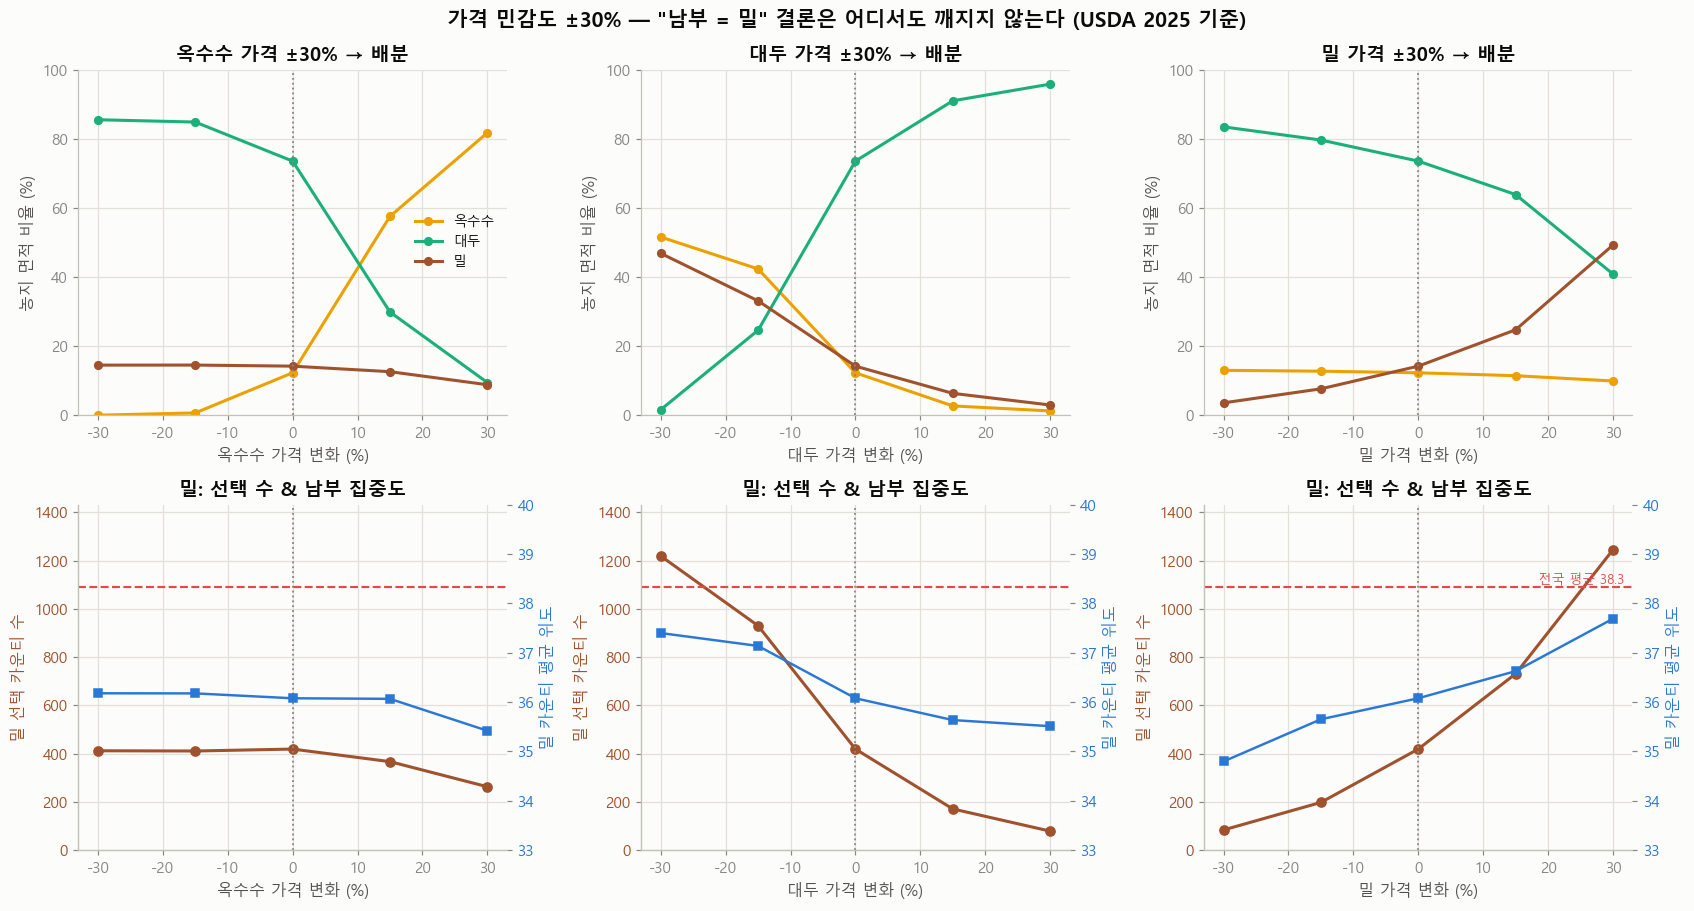

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15.5, 8.4))
CC = {'옥수수': CORN_C, '대두': SOY_C, '밀': WHEAT_C}

for j, c in enumerate(CROPS):
    ko = CROP_KO[c]
    t = sens[sens.흔든작물 == ko].sort_values('변화_pct')

    # 위: 작물별 면적 점유율
    ax = axes[0, j]
    for col, lab in [('옥수수_pct', '옥수수'), ('대두_pct', '대두'), ('밀_pct', '밀')]:
        ax.plot(t.변화_pct, t[col], '-o', color=CC[lab], ms=5, label=lab)
    ax.axvline(0, color=MUTED, ls=':', lw=1.2)
    ax.set_xlabel('%s 가격 변화 (%%)' % ko)
    ax.set_ylabel('농지 면적 비율 (%)')
    ax.set_title('%s 가격 ±30%% → 배분' % ko)
    ax.set_ylim(0, 100)
    if j == 0:
        ax.legend(frameon=False, fontsize=9)

    # 아래: 밀 카운티 수 + 밀 평균위도
    ax = axes[1, j]
    ax.plot(t.변화_pct, t.밀_카운티, '-o', color=WHEAT_C, ms=6)
    ax.axvline(0, color=MUTED, ls=':', lw=1.2)
    ax.set_xlabel('%s 가격 변화 (%%)' % ko)
    ax.set_ylabel('밀 선택 카운티 수', color=WHEAT_C)
    ax.tick_params(axis='y', labelcolor=WHEAT_C)
    ax.set_ylim(0, max(sens.밀_카운티) * 1.15)

    ax2 = ax.twinx()
    ax2.plot(t.변화_pct, t.밀_평균위도, '-s', color=BLUE, ms=5, lw=1.6)
    ax2.axhline(LAT_ALL, color=RED, ls='--', lw=1.4)
    ax2.set_ylabel('밀 카운티 평균 위도', color=BLUE)
    ax2.tick_params(axis='y', labelcolor=BLUE)
    ax2.set_ylim(33, 40)
    ax2.grid(False)
    if j == 2:
        ax2.text(0.98, LAT_ALL, ' 전국 평균 %.1f' % LAT_ALL, transform=ax2.get_yaxis_transform(),
                 ha='right', va='bottom', fontsize=8.5, color=RED)
    ax.set_title('밀: 선택 수 & 남부 집중도')

fig.suptitle('가격 민감도 ±30%% — "남부 = 밀" 결론은 어디서도 깨지지 않는다 (USDA %d 기준)' % YEAR,
             fontsize=13.5, fontweight='semibold')
fig.tight_layout()
save(fig, 'fig50_usda_price_sensitivity.png'); plt.show()

## 4. 요약

In [13]:
print('=' * 84)
print((' 12 · USDA 실측 가격 교체 — 요약').center(84))
print('=' * 84)

print()
print('[1] 추출한 USDA 값 (ERS Commodity Costs and Returns, %d, U.S. total)' % YEAR)
for _, r in usda.iterrows():
    print('    %-4s 가격 %5.2f $/bu · 변동비 %6.2f $/ac   (수동 확인값과 일치 ✓)'
          % (r.crop_ko, r.price_usd_per_bu, r.opcost_usd_per_acre))
print('    → 3작물 × 2항목 = 6개 값 전부 사용자 확인값과 정확히 일치. 불일치 없음.')

print()
print('[2] 하드코딩 → USDA: 결과가 얼마나 바뀌었나')
print('    옥수수 면적  %.1f%% → %.1f%%   (하드코딩이 옥수수를 크게 과대평가했다)'
      % (HARD['sh_unc'][CORN], USDA['sh_unc'][CORN]))
print('    대두 면적    %.1f%% → %.1f%%' % (HARD['sh_unc'][SOY], USDA['sh_unc'][SOY]))
print('    밀 면적      %.1f%% → %.1f%%   (밀 카운티 %d → %d 개)'
      % (HARD['sh_unc'][WHEAT], USDA['sh_unc'][WHEAT], HARD['n_wheat_unc'], USDA['n_wheat_unc']))
print('    회복률       %.2f%% → %.2f%% (무제약) · %.2f%% → %.2f%% (제약)'
      % (HARD['rec_unc'], USDA['rec_unc'], HARD['rec_con'], USDA['rec_con']))
print('    → 배분(작물 점유율)은 크게 바뀌지만, 적응의 성과(회복률)는 같은 자릿수를 유지한다.')

print()
print('[3] "남부 고온지역 = 밀" 결론')
print('    가격 ±30% 15개 시나리오 전부에서:')
print('      · 밀이 항상 선택된다 (%d ~ %d 카운티, 0인 경우 없음)'
      % (sens.밀_카운티.min(), sens.밀_카운티.max()))
print('      · 밀 카운티 평균 위도 %.1f ~ %.1f — 전국 평균 %.1f 보다 항상 남쪽'
      % (sens.밀_평균위도.min(), sens.밀_평균위도.max(), LAT_ALL))
print('      · 상위 주 OK·TX·KS·GA·MO·VA·AR·MS 로 일관')
print('    → ROBUST. 가격 가정이 흔들려도 이 결론은 살아남는다.')

print()
print('[4] 강건하지 *않은* 것')
print('    작물별 면적 점유율은 가격에 따라 폭 %.0f~%.0f%%p 로 움직인다.'
      % (min(sens[c].max() - sens[c].min() for c in ['옥수수_pct', '대두_pct', '밀_pct']),
         max(sens[c].max() - sens[c].min() for c in ['옥수수_pct', '대두_pct', '밀_pct'])))
print('    → "옥수수 X% / 대두 Y%" 같은 점추정치는 발표에서 단정하지 말 것.')

print()
print('[5] 최적화 기계는 그대로 잘 돈다')
print('    TS 최적성 갭 %.5f%% (하드코딩) · %.5f%% (USDA) · 실현가능 %s/%s'
      % (HARD['gap_pct'], USDA['gap_pct'], HARD['feasible'], USDA['feasible']))
print('    → 가격을 바꿔도 라그랑주 상한 대비 갭은 여전히 0.01% 미만.')
print('=' * 84)

                               12 · USDA 실측 가격 교체 — 요약                              

[1] 추출한 USDA 값 (ERS Commodity Costs and Returns, 2025, U.S. total)
    옥수수  가격  3.93 $/bu · 변동비 440.11 $/ac   (수동 확인값과 일치 ✓)
    대두   가격  9.76 $/bu · 변동비 244.80 $/ac   (수동 확인값과 일치 ✓)
    밀    가격  5.05 $/bu · 변동비 155.52 $/ac   (수동 확인값과 일치 ✓)
    → 3작물 × 2항목 = 6개 값 전부 사용자 확인값과 정확히 일치. 불일치 없음.

[2] 하드코딩 → USDA: 결과가 얼마나 바뀌었나
    옥수수 면적  38.5% → 12.3%   (하드코딩이 옥수수를 크게 과대평가했다)
    대두 면적    53.8% → 73.5%
    밀 면적      7.6% → 14.2%   (밀 카운티 213 → 419 개)
    회복률       19.12% → 16.65% (무제약) · 17.35% → 13.99% (제약)
    → 배분(작물 점유율)은 크게 바뀌지만, 적응의 성과(회복률)는 같은 자릿수를 유지한다.

[3] "남부 고온지역 = 밀" 결론
    가격 ±30% 15개 시나리오 전부에서:
      · 밀이 항상 선택된다 (79 ~ 1245 카운티, 0인 경우 없음)
      · 밀 카운티 평균 위도 34.8 ~ 37.7 — 전국 평균 38.3 보다 항상 남쪽
      · 상위 주 OK·TX·KS·GA·MO·VA·AR·MS 로 일관
    → ROBUST. 가격 가정이 흔들려도 이 결론은 살아남는다.

[4] 강건하지 *않은* 것
    작물별 면적 점유율은 가격에 따라 폭 46~94%p 로 움직인다.
    → "옥수수 X% / 대두 Y%" 같은 점추정치는 발표에서 단정하지 말 것.

[5] 최적화 기계는 그대로 

## 5. 이상한 점 / 한계 — 정직하게

**(1) x̄ 가 현실과 너무 다르다.** USDA 값으로는 "현재 배분" x̄ 가 옥수수 17.5% / 대두 70.2% 가 된다.
실제 미국은 옥수수와 대두 재배면적이 대략 비슷하다. 원인은 x̄ 를 **재배면적 데이터가 아니라
"관측 수확량 × 가격의 argmax"** 로 근사했기 때문이다 (06 §한계에 이미 기재된 문제).
가격이 옥수수에 불리해지자 이 근사의 취약함이 드러난 것이다.
→ x̄ 는 "현재 재배 현황"이 아니라 **"현재 가격에서 각 카운티가 골랐어야 할 작물"** 로 읽어야 한다.
   회복률이 100% 를 넘을 수 있다는 06 의 경고와 같은 뿌리다.

**(2) USDA 2025 값에서 옥수수는 거의 이윤이 안 난다.** 가격 3.93 × 전국평균 예측수확량 ≈ 468 $/ac
에서 변동비 440 $/ac 를 빼면 마진이 ~28 $/ac 다. 대두(~102)·밀(~67)보다 훨씬 낮다.
2025 는 곡물가 하락 + 투입재가 상승이 겹친 해라 **옥수수에 유난히 나쁜 연도**다.
단일 연도 스냅샷을 쓰는 것 자체가 새로운 편향을 만든다.
→ 발표에서는 "2025년 조건에서는" 이라고 연도를 명시할 것. 여러 해 평균도 대안이다.

**(3) 밀 모델의 구조적 불리함은 그대로다.** 밀 모델은 1981–2007 만 학습했고 (04c),
x̄ 산정에서도 2008년 이후 관측이 없어 전체기간 평균을 쓴다 (10 §3).
즉 **밀은 여전히 과소평가된 상태**이고, 그런데도 USDA 값에서 밀 면적이 배로 늘었다.
→ 밀의 진짜 잠재력은 여기서 보이는 것보다 **더 클 수 있다.** 결론의 방향은 보수적이다.

**(4) 온난화 손실률이 21.4% → 25.5% 로 커졌다.** 손실은 $ 단위라 가격 스케일에 딸려간다.
"손실 25%" 같은 수치도 가격 조건부다.

**(5) 변동비만 쓴다 (고정비 제외).** ERS 의 `Total, operating costs` 만 사용하고
토지임차료·감가상각 등 `allocated overhead` 는 뺐다. 작물 선택 argmax 를 바꾸지 않으므로
의도적인 선택이지만, 그래서 여기 v 는 "순이익" 이 아니라 **기여마진(contribution margin)** 이다.
→ 발표에서 "순이익" 이라고 부르지 말 것.